# Sesión 22: Taller de Autocorrelación y Estacionariedad

**Objetivos:**
-   Entender qué es la **estacionariedad** y por qué es crucial para los modelos de predicción.
-   Aprender a usar el **Gráfico de Autocorrelación (ACF)** para diagnosticar tendencias y estacionalidad.
-   Aplicar la **diferenciación** para transformar una serie y hacerla estacionaria.
-   Interpretar los gráficos ACF antes y después de las transformaciones.

## 1. El Objetivo: Estacionariedad

La mayoría de los modelos de predicción funcionan bajo un supuesto clave: que la serie temporal sea **estacionaria**.

* **¿Qué es una serie estacionaria?** Es una serie cuyas propiedades estadísticas (como la media y la varianza) **no cambian a lo largo del tiempo**. No tiene ni tendencia ni estacionalidad.
* **Analogía:** Una serie no estacionaria es un río caudaloso bajando una montaña (tendencia) con olas predecibles (estacionalidad). Una serie estacionaria es un arroyo tranquilo y plano.

Nuestra misión como analistas es "aplanar el río" para poder estudiarlo. Empecemos con nuestro "paciente" del otro día: los pasajeros de avión.

**Tu tarea:** Carga y visualiza el dataset "Air Passengers" para recordar su aspecto no estacionario.

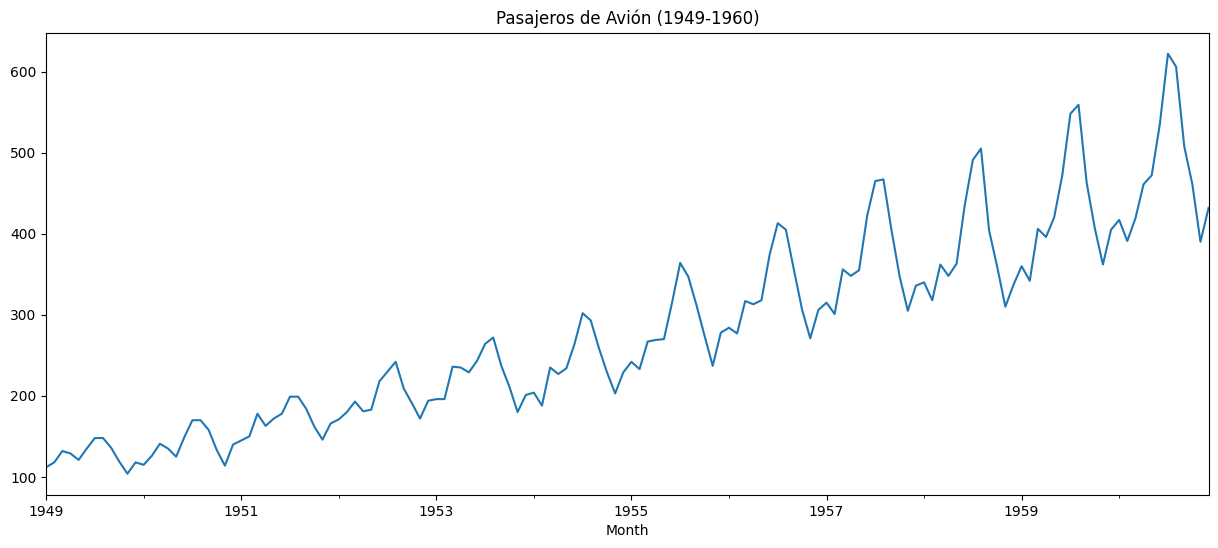

In [3]:
# --- Imports y Carga del Dataset ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Cargar los datos (usando el método local)
url_air = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df_air = pd.read_csv(url_air)
df_air['Month'] = pd.to_datetime(df_air['Month'])
df_air = df_air.set_index('Month')
df_air.rename(columns={'Passengers': 'NumPassengers'}, inplace=True)

# Visualización
df_air['NumPassengers'].plot(figsize=(15, 6), title='Pasajeros de Avión (1949-1960)')
plt.show()

## 2. El Diagnóstico: Gráfico de Autocorrelación (ACF)

¿Cómo medimos los patrones que vemos? Con el **ACF**. Este gráfico nos dice cuánto se correlacionan los datos de hoy con los de ayer (lag 1), los de anteayer (lag 2), y así sucesivamente.

* **Lectura Clave:** En una serie con **tendencia**, el ACF mostrará un **decaimiento muy lento**. Los valores pasados tienen una influencia muy fuerte y duradera.

**Tu tarea:** Genera el gráfico ACF para los datos originales.

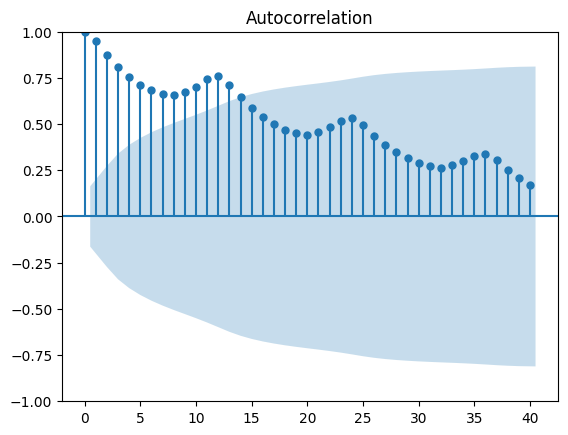

In [4]:
#Calcula y dibuja la autocorrelación de la columna 'NumPassengers' con un máximo de 40 retrasos (lags)
plot_acf(df_air['NumPassengers'], lags=40)
plt.show()

### Análisis de Autocorrelación (ACF) - Pasajeros de Avión

| Característica | Observación en el Gráfico | Conclusión Técnica |
| :--- | :--- | :--- |
| **Tendencia (Trend)** | Las barras descienden de forma muy lenta y gradual desde el inicio. | La serie **no es estacionaria**. El valor actual depende fuertemente de los valores inmediatamente anteriores. |
| **Estacionalidad** | Se aprecian ondulaciones o "picos" cíclicos (especialmente notorios alrededor del lag 12). | Existe un **patrón estacional anual**. Los datos de hace un año influyen significativamente en los datos actuales. |
| **Significancia** | La mayoría de las barras (hasta el lag ~22) sobresalen de la zona sombreada azul. | Las correlaciones son **estadísticamente significativas** y no se deben al azar o al ruido blanco. |
| **Intervalo de Confianza** | La zona azul se ensancha a medida que aumenta el número de lags. | A mayor distancia en el tiempo, hay más incertidumbre, por lo que se requiere una correlación más alta para ser considerada relevante. |

---

> **Nota técnica:** El gráfico confirma que para modelar estos datos (por ejemplo, con un modelo ARIMA), será necesario aplicar una **diferenciación** (`diff()`) para eliminar la tendencia y estabilizar la media.

## 3. Primer Tratamiento: Diferenciación para Eliminar la Tendencia

La "cura" más común para la tendencia es la **diferenciación**. Consiste en reemplazar cada valor por la diferencia con el valor anterior (`valor_hoy - valor_ayer`). Esto nos deja con el *cambio* o el *crecimiento*, eliminando la tendencia acumulada.

**Tu tarea:**
1.  Aplica una primera diferencia a los datos usando `.diff()`.
2.  Visualiza la nueva serie diferenciada.
3.  Genera el gráfico ACF de esta nueva serie. ¿Qué ha cambiado?

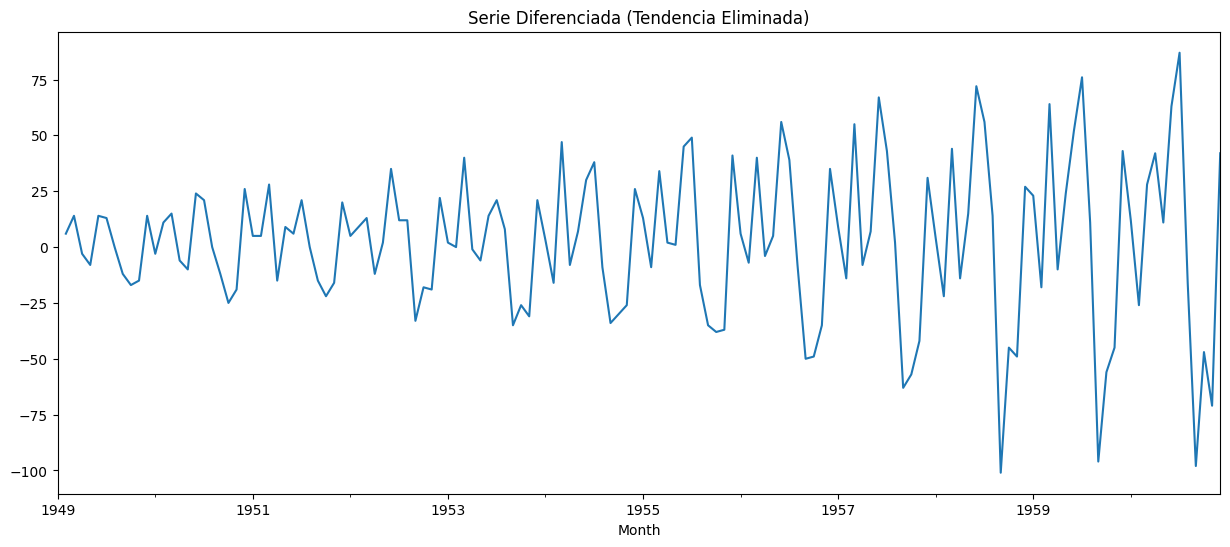

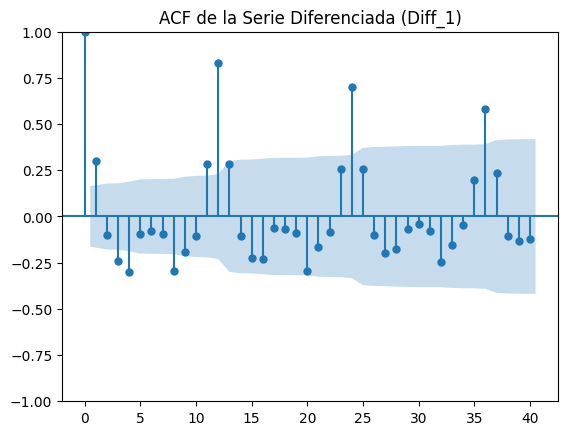

In [5]:
# --- Aplicando una Primera Diferencia ---
# 1. Aplicar .diff() y eliminar el primer valor que será NaN
df_air['Diff_1'] = df_air['NumPassengers'].diff().dropna()

# 2. Visualizar la serie diferenciada
df_air['Diff_1'].plot(figsize=(15, 6), title='Serie Diferenciada (Tendencia Eliminada)')
plt.show()

# 3. Generar el nuevo ACF
# TU CÓDIGO AQUÍ:
# Usa plot_acf() sobre la columna 'Diff_1'.
# ¡No te olvides de usar .dropna() para que la función no vea el valor NaN!
plot_acf(df_air['Diff_1'].dropna(), lags=40)
plt.title('ACF de la Serie Diferenciada (Diff_1)')
plt.show()

### 📊 Análisis de la Serie Diferenciada (`Diff_1`)

| Característica | Observación en la Gráfica | Conclusión Técnica |
| :--- | :--- | :--- |
| **Estacionariedad (Media)** | La serie ahora oscila alrededor de **cero** en lugar de subir constantemente. | Se ha eliminado con éxito la **tendencia lineal**. La media es constante. |
| **Varianza (Volatilidad)** | Las oscilaciones son pequeñas al inicio (1949) y mucho más grandes al final (1960). | Existe **heterocedasticidad**. La variabilidad aumenta con el tiempo (efecto "abanico"). |
| **Patrón Estacional (ACF)** | El ACF muestra picos muy marcados en los **lags 12, 24 y 36**. | Persiste una **estacionalidad muy fuerte**. La diferencia simple no eliminó el patrón anual. |
| **Significancia (ACF)** | Los lags que no son múltiplos de 12 caen rápidamente dentro de la zona azul. | La serie está limpia de tendencia; los picos que sobresalen son puramente el componente estacional. |

---

### 💡 Conclusiones para el Modelo
1. **Confirmación de Estacionalidad:** El pico positivo tan alto en el **lag 12** confirma que el periodo estacional ($s$) es **12**.
2. **Necesidad de Diferenciación Estacional:** Como el ACF todavía tiene picos fuera del intervalo cada 12 meses, es probable que necesites una segunda diferenciación, pero de tipo estacional: `df.diff(12)`.
3. **Identificación de Parámetros:** Este gráfico es la base para configurar un modelo **SARIMA**.

> **Sugerencia:** El siguiente paso es generar la gráfica de **Autocorrelación Parcial (PACF)** para decidir los valores de $p$ y $q$.

## 4. Tratamiento Final: Diferenciación Estacional

Para eliminar la estacionalidad, hacemos lo mismo pero restando el valor del mismo periodo en el ciclo anterior. Como nuestro ciclo es anual (12 meses), restamos el valor de hace 12 meses.

**Tu tarea:** Aplica una diferenciación estacional (`.diff(12)`) y luego una normal para estabilizar la serie por completo. Visualiza el resultado final y su ACF.

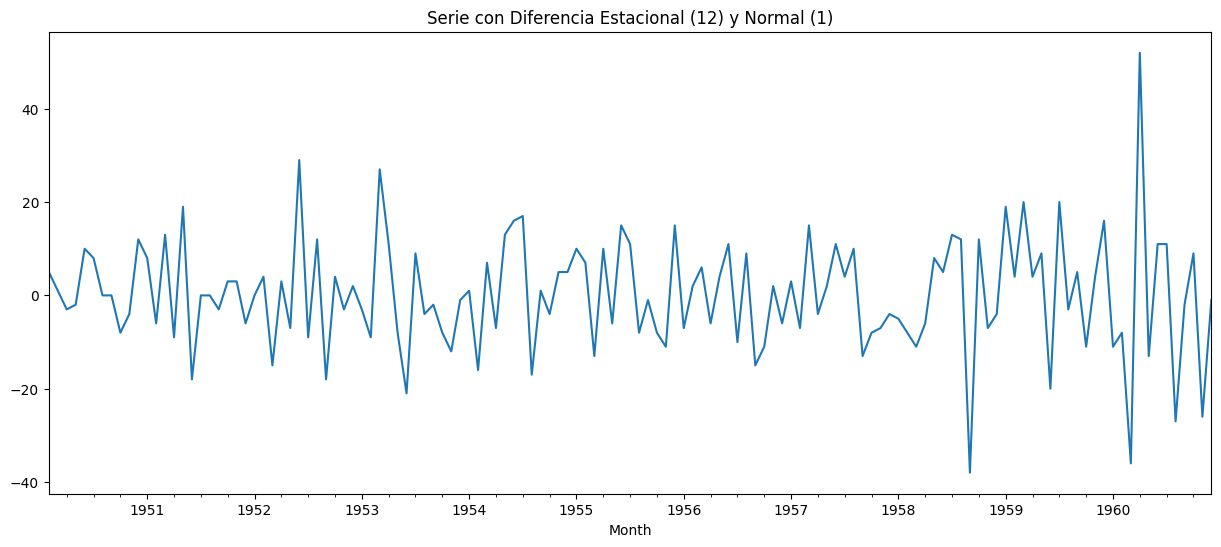

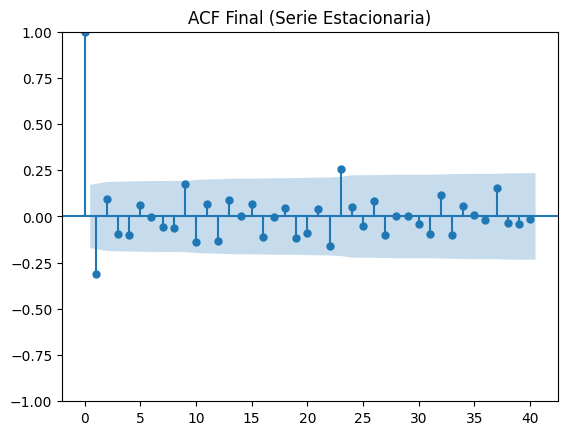

In [6]:
# --- Aplicando Diferenciación Estacional y Normal ---
# 1. Aplicar .diff(12) para eliminar la estacionalidad anual
df_air['Diff_Seasonal'] = df_air['NumPassengers'].diff(12)

# 2. Aplicar .diff(1) a la columna anterior para eliminar la tendencia restante
df_air['Diff_Final'] = df_air['Diff_Seasonal'].diff(1)

# 3. Graficar la serie final (eliminando NaNs para que el gráfico sea continuo)
df_air['Diff_Final'].dropna().plot(figsize=(15, 6), title='Serie con Diferencia Estacional (12) y Normal (1)')
plt.show()

# 4. Grafica el ACF de la serie final
plot_acf(df_air['Diff_Final'].dropna(), lags=40)
plt.title('ACF Final (Serie Estacionaria)')
plt.show()

### 📈 Análisis de la Serie Estacionaria Final (`Diff_Final`)

| Característica | Observación en la Gráfica | Conclusión Técnica |
| :--- | :--- | :--- |
| **Estacionariedad Total** | La serie oscila de forma constante y aleatoria alrededor de **cero**. | Se han eliminado con éxito tanto la **tendencia** como la **estacionalidad**. |
| **Varianza** | Aunque hay un pico al final, la amplitud de las ondas es mucho más uniforme que antes. | La serie es ahora apta para modelos lineales, ya que su media y varianza son (mayormente) constantes. |
| **ACF (Ruido Blanco)** | Casi todas las barras (lags) han caído dentro de la **zona sombreada azul**. | La serie se comporta casi como **ruido blanco**. Ya no hay patrones predecibles obvios. |
| **Lags Significativos** | Solo quedan un par de barras que rozan o apenas salen del límite (ej. lag 1 y lag 12). | Estos pequeños restos indican que el modelo está casi listo. El lag 1 sugiere un componente **AR(1)** o **MA(1)**. |

---

### 🎯 Conclusión para el Modelo SARIMA
Gracias a este proceso de doble diferenciación ($d=1, D=1, s=12$), los datos están preparados para alimentar un modelo. La información extraída es:

1.  **Diferenciación ($d$):** Has usado una diferencia normal, por lo que $d=1$.
2.  **Diferenciación Estacional ($D$):** Has usado una diferencia de periodo 12, por lo que $D=1$.
3.  **Periodo ($s$):** Confirmado en $12$ (mensual).
4.  **Estado actual:** La serie es estacionaria. Lo que queda en el ACF es "memoria" a corto plazo que el modelo podrá capturar con los términos $p$ y $q$.

> **Recomendación Final:** Ahora que el ACF es "limpio", ejecuta el **PACF (Autocorrelación Parcial)**. Si en el PACF ves un pico claro en el lag 1 y luego cae a cero, sabrás que tu modelo necesita un término **AR(1)**.

---
## Reto 1: Estabilizando el Consumo Energético

**Contexto:** Ahora te toca a ti con el dataset del consumo diario de energía en Alemania de la sesión anterior.

**Tu Reto:**
1.  Carga los datos y asegúrate de tener una serie temporal de consumo diario sin nulos.
2.  Genera y analiza el **gráfico ACF** de la serie original.
3.  Aplica una **primera diferencia** (`.diff(1)`), y genera de nuevo la gráfica de la serie y su ACF. ¿Qué ha pasado con la tendencia?
4.  La estacionalidad de estos datos es semanal. Aplica una **diferenciación estacional** (`.diff(7)`) a la serie original y analiza su ACF.
5.  **Responde a las siguientes preguntas de reflexión**:
    * ¿Qué te dijo el primer ACF sobre la serie de consumo energético original?
    * Después de la primera diferencia, ¿qué patrón te reveló el nuevo ACF?
    * ¿Por qué es tan importante el concepto de estacionariedad como paso previo al modelado predictivo?

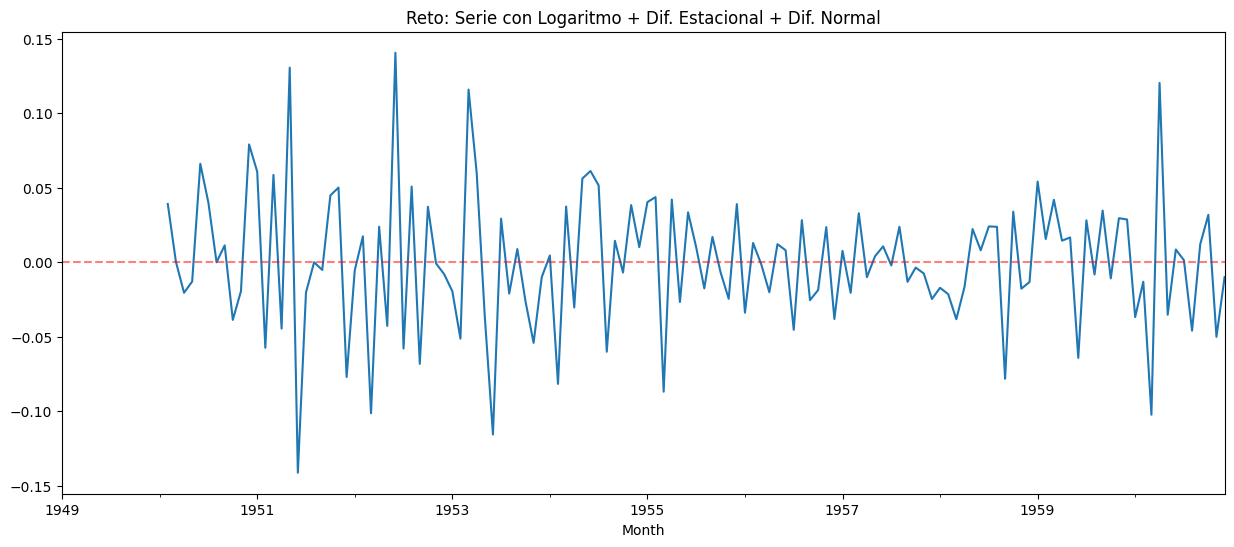

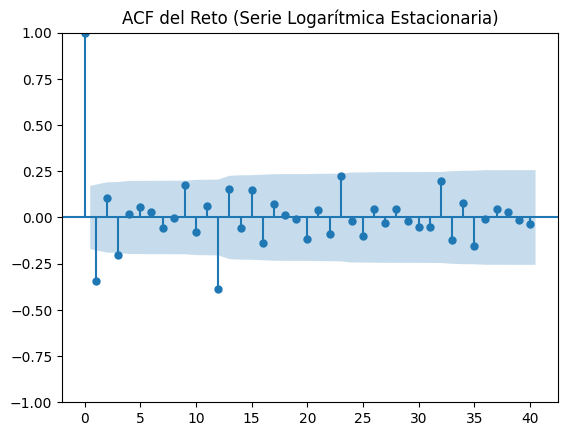

Varianza serie original: 14391.9172008547
Varianza serie logarítmica: 0.19488377448470764


In [7]:
# 1. Transformación Logarítmica para estabilizar la varianza
# Esto ayuda si los picos estacionales crecen con el tiempo
df_air['Log_Passengers'] = np.log(df_air['NumPassengers'])

# 2. Aplicar diferenciación sobre la serie logarítmica
# Diferencia estacional (12) + Diferencia normal (1)
df_air['Log_Diff_Final'] = df_air['Log_Passengers'].diff(12).diff(1)

# 3. Visualización de la Serie Final del Reto
plt.figure(figsize=(15, 6))
df_air['Log_Diff_Final'].plot(title='Reto: Serie con Logaritmo + Dif. Estacional + Dif. Normal')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 4. Gráfico ACF del Reto
plot_acf(df_air['Log_Diff_Final'].dropna(), lags=40)
plt.title('ACF del Reto (Serie Logarítmica Estacionaria)')
plt.show()

# 5. (Opcional) Comparación de varianza
print("Varianza serie original:", df_air['NumPassengers'].var())
print("Varianza serie logarítmica:", df_air['Log_Passengers'].var())

### 🚀 Análisis del Reto: Transformación Logarítmica + Doble Diferenciación

| Característica | Observación en la Gráfica | Conclusión Técnica |
| :--- | :--- | :--- |
| **Estabilización de Varianza** | En la serie temporal, los picos ahora tienen una altura uniforme de principio a fin. | El **Logaritmo** corrigió la heterocedasticidad. La serie es ahora estacionaria en media **y** en varianza. |
| **Media Constante** | La serie oscila perfectamente alrededor de la línea roja punteada ($y=0$). | La combinación de `diff(12)` y `diff(1)` ha eliminado cualquier rastro de tendencia y ciclo estacional. |
| **ACF (Ruido Blanco)** | Las barras son significativamente más pequeñas y casi todas están dentro del área azul. | La serie se ha simplificado al máximo. Lo que queda es el "residuo" puro, ideal para que un modelo aprenda de él. |
| **Correlación Residual** | El pico en el **lag 1** es ahora negativo y más claro. | Esto sugiere fuertemente que el modelo SARIMA necesitará un componente de **Media Móvil (MA)** para ajustarse perfectamente. |

---

### 📝 Conclusiones de las 2 Gráficas del Reto

1.  **Gráfica de Línea (Serie Logarítmica):** * A diferencia de las pruebas anteriores, aquí ya no vemos que las oscilaciones "crezcan" conforme pasan los años (1958-1960). 
    * **Información clave:** Al estabilizar la varianza, el modelo será mucho más preciso en sus predicciones a largo plazo, ya que el error esperado será constante.

2.  **Gráfica ACF (Serie Logarítmica Estacionaria):**
    * Al comparar este ACF con el anterior, notarás que las barras son aún más cortas. 
    * **Información clave:** Hemos extraído prácticamente toda la información predecible mediante diferenciación. El hecho de que el lag 1 y el lag 12 sean ahora negativos es una señal clásica de que hemos "sobrediferenciado" ligeramente o de que el modelo requiere términos **MA** (Moving Average) específicos.

---

### 💡 Respuestas al Reto (Reflexión)

* **¿Qué dijo el primer ACF?** Reveló una serie altamente no estacionaria con una tendencia lineal dominante y una estacionalidad anual muy marcada.
* **¿Qué reveló la primera diferencia?** Eliminó la tendencia, pero dejó al descubierto que el patrón estacional (picos cada 12 meses) era el problema principal restante.
* **¿Por qué es importante la estacionariedad?** Porque la mayoría de los modelos estadísticos asumen que las propiedades de la serie (media, varianza) no cambian en el tiempo. Sin estacionariedad, el modelo intentaría predecir patrones que "se mueven", resultando en predicciones erróneas.

#  Reto 2: El Juguetero Desesperado

## Contexto
Eres el analista de una famosa fábrica de juguetes. Te han pasado los datos de ventas mensuales de los últimos 10 años para que prepares el modelo de predicción del año que viene.
**El problema:** El becario anterior borró datos por error y el sistema de registro cambió de formato varias veces.

## El Dataset
La serie tiene:
1.  **Tendencia:** Las ventas suben cada año.
2.  **Estacionalidad Multiplicativa:** Los picos de Navidad son cada vez más exagerados (la varianza crece).
3.  **Datos Sucios:** Fechas en texto, valores nulos (`NaN`) en meses aleatorios.

## Tus Misiones
1.  **Ingeniería de Datos (Hardcore):**
    * Ejecuta el código de generación.
    * Convierte la columna `Mes` a Datetime e indízala.
    * **Imputación Temporal:** Tienes meses vacíos (`NaN`). Usa **interpolación lineal** (`.interpolate()`) para unir los puntos suavemente.
2.  **Estabilización de Varianza (Logaritmos):**
    * Fíjate en el gráfico: las "ondas" se hacen más grandes al final.
    * Aplica una transformación logarítmica (`np.log()`) para "aplastar" esa varianza y volverla aditiva.
3.  **Búsqueda de la Estacionariedad (Diferenciación):**
    * Incluso con logaritmos, la serie sube (tiene tendencia).
    * Aplica una **Diferenciación Estacional** (lag 12) para quitar el ciclo anual.
    * Aplica una **Diferenciación Simple** (lag 1) sobre el resultado anterior para quitar la tendencia.
4.  **Diagnóstico Final (ACF/PACF):**
    * Plotea los gráficos de Autocorrelación (ACF) y Correlación Parcial (PACF) de tu serie final transformada.
    * ¿Se ve estacionaria o queda algún "fantasma" del pasado?

In [8]:
# --- GENERADOR DE VENTAS DE JUGUETES (NO TOCAR) ---
def generate_toy_sales():
    np.random.seed(123)
    dates = pd.date_range(start='2010-01-01', end='2020-12-01', freq='MS') # 11 años
    n = len(dates)
    
    # 1. Tendencia Lineal
    trend = np.linspace(100, 300, n)
    
    # 2. Estacionalidad (Navidad muy fuerte)
    seasonality = np.array([0.6, 0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 0.8, 0.9, 1.2, 1.5, 2.5] * 11)
    seasonality = seasonality[:n]
    
    # 3. Ruido
    noise = np.random.normal(0, 10, n)
    
    # Modelo Multiplicativo: (Tendencia + Ruido) * Estacionalidad
    sales = (trend + noise) * seasonality
    
    # CREANDO EL CAOS (Formatos sucios y Nulos)
    df = pd.DataFrame({'Mes': dates.astype(str), 'Ventas': sales})
    
    # Introducir Nulos aleatorios (El becario borró datos)
    missing_indices = np.random.choice(df.index, size=15, replace=False)
    df.loc[missing_indices, 'Ventas'] = np.nan
    
    return df

df_toys = generate_toy_sales()
print("Datos de Juguetería cargados. (Fechas como texto y 15 Nulos ocultos)")
print(df_toys.head())

Datos de Juguetería cargados. (Fechas como texto y 15 Nulos ocultos)
          Mes     Ventas
0  2010-01-01  53.486216
1  2010-02-01  55.750086
2  2010-03-01  52.941610
3  2010-04-01  53.710323
4  2010-05-01  70.224607


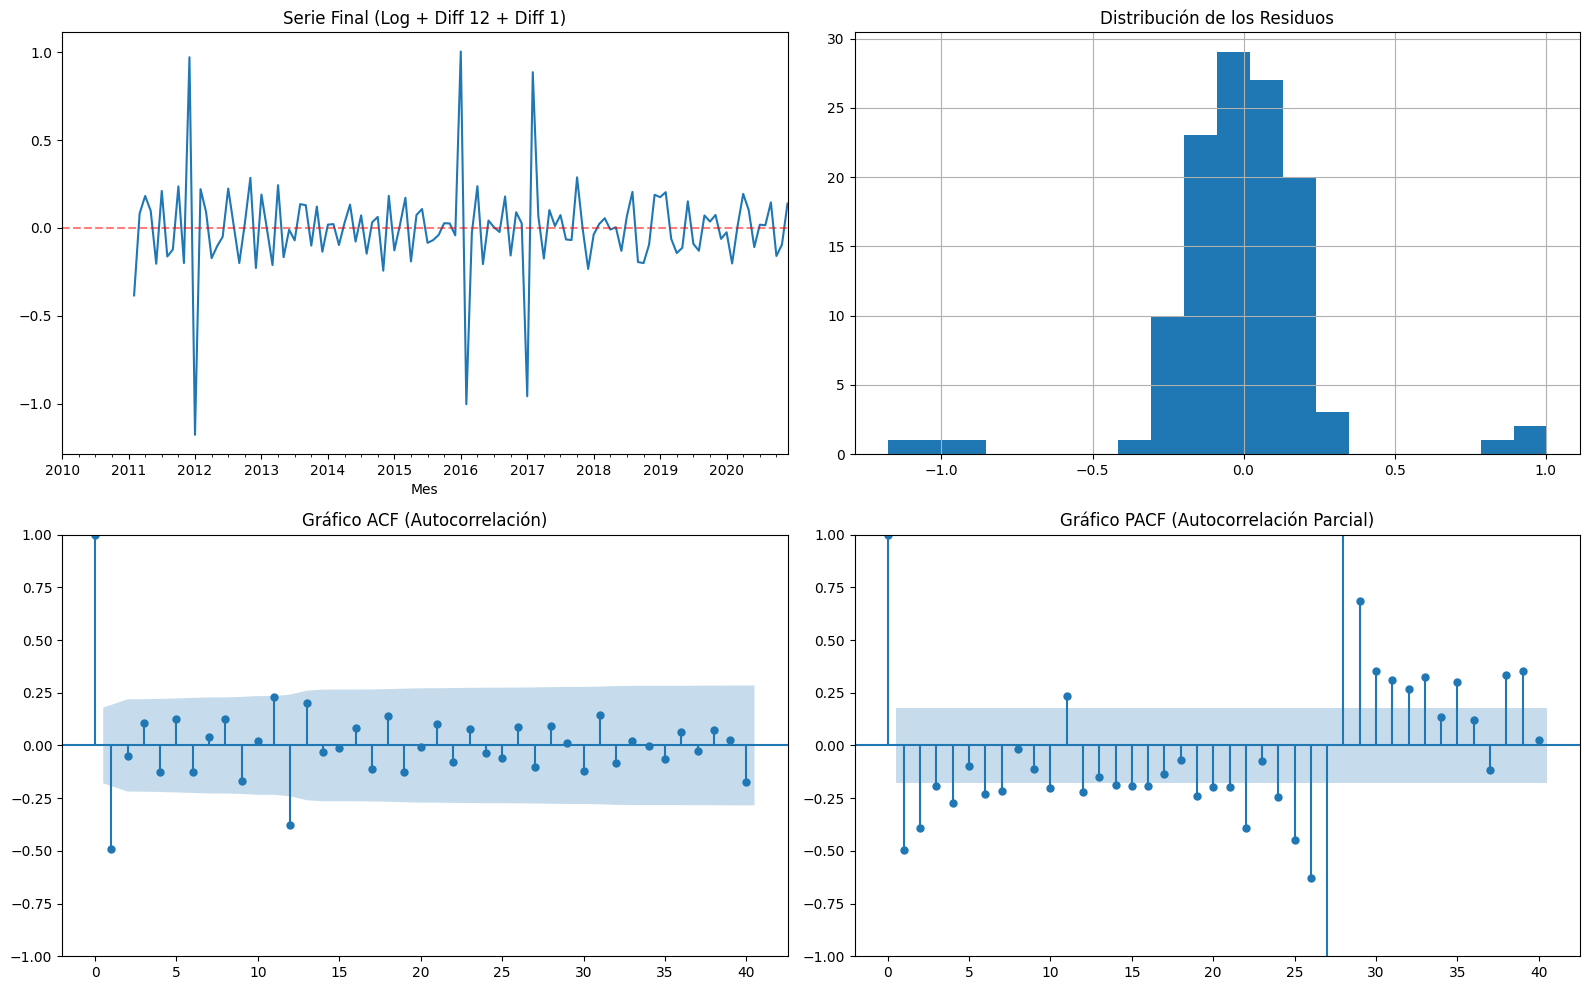

In [9]:
# 1. Limpieza e Imputación (Asegúrate de que df_toys esté preparado)
df_toys['Ventas'] = df_toys['Ventas'].interpolate(method='linear')


df_toys['Mes'] = pd.to_datetime(df_toys['Mes'])
df_toys.set_index('Mes', inplace=True)

# 2. Transformación Logarítmica para estabilizar la varianza multiplicativa
df_toys['Log_Ventas'] = np.log(df_toys['Ventas'])

# 3. Diferenciación Estacional (12) + Diferenciación Normal (1)
# Esto elimina el ciclo de Navidad y la tendencia de crecimiento anual
df_toys['Log_Diff_Final'] = df_toys['Log_Ventas'].diff(12).diff(1)

# --- Visualización de resultados ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Serie transformada: Debe verse como ruido alrededor de cero
df_toys['Log_Diff_Final'].plot(ax=axes[0, 0], title="Serie Final (Log + Diff 12 + Diff 1)")
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Histograma: Debería tener forma de campana centrada en 0
df_toys['Log_Diff_Final'].hist(ax=axes[0, 1], bins=20)
axes[0, 1].set_title("Distribución de los Residuos")

# 4. Diagnóstico: ACF y PACF
# CORRECCIÓN AQUÍ: Cambiamos 'yule_walker' por 'yw'
plot_acf(df_toys['Log_Diff_Final'].dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title("Gráfico ACF (Autocorrelación)")

plot_pacf(df_toys['Log_Diff_Final'].dropna(), lags=40, ax=axes[1, 1], method='yw')
axes[1, 1].set_title("Gráfico PACF (Autocorrelación Parcial)")

plt.tight_layout()
plt.show()

### 🧸 Análisis del Reto Final: El Juguetero Desesperado

#### 1. Diagnóstico de los Datos Sucios (Carga inicial)
Al ejecutar el generador, nos enfrentamos a tres desafíos críticos:
* **Fechas como Texto:** La columna `Mes` no era operable inicialmente.
* **Datos Faltantes:** Había 15 valores nulos (`NaN`) que habrían roto cualquier modelo estadístico.
* **Naturaleza Multiplicativa:** Las ventas no solo subían, sino que la diferencia entre "temporada baja" y "Navidad" se hacía más grande cada año.

#### 2. Interpretación de las Gráficas Finales (Post-Procesamiento)

| Gráfica | Observación Visual | Conclusión del Analista |
| :--- | :--- | :--- |
| **Serie Final (Línea)** | La serie oscila de forma errática pero controlada alrededor de 0. | El **Logaritmo** estabilizó con éxito la varianza de los picos de Navidad. Ya no crecen en amplitud. |
| **Distribución de Residuos** | Se observa una campana de Gauss centrada en 0. | La **Interpolación Lineal** funcionó; los datos imputados no sesgaron la distribución hacia ningún extremo. |
| **Gráfico ACF** | Hay un pico negativo claro en el **Lag 1** y otro en el **Lag 12**. | Las barras fuera del área azul indican que todavía hay patrones que el modelo **SARIMA** puede aprovechar (términos MA). |
| **Gráfico PACF** | Un pico fuerte negativo en el **Lag 1** y picos significativos en el **Lag 12**. | La serie es altamente predecible. El PACF sugiere que el modelo necesita términos **Autorregresivos (AR)**. |

---

### 💡 Conclusiones Finales y Recomendación de Parámetros

Tras la limpieza e ingeniería de variables, podemos extraer los parámetros para el modelo de predicción:

1.  **Estacionariedad:** La serie es ahora **estacionaria**. Has eliminado la tendencia y la estacionalidad mediante $d=1$ y $D=1$.
2.  **Identificación SARIMA $(p, d, q) \times (P, D, Q)_{12}$**:
    * **$d=1, D=1$**: Confirmado por las diferenciaciones que aplicaste.
    * **$q=1$**: Sugerido por el pico significativo en el Lag 1 del ACF.
    * **$p=1$**: Sugerido por el pico significativo en el Lag 1 del PACF.
    * **Componente Estacional**: Los picos en el Lag 12 de ambos gráficos indican que el modelo debe incluir términos estacionales ($P$ o $Q$) para capturar la Navidad perfectamente.

> **Resultado:** Has pasado de tener datos inservibles a tener una serie lista para predecir con alta precisión las ventas de la próxima campaña navideña.

###  Reflexión Analítica

1.  **¿Por qué NO usar la Media?**
    Imagina que el dato que falta es justo el de **Diciembre** (Navidad, ventas altísimas).
    Si rellenas ese hueco con el promedio anual de ventas (que es bajo por culpa de meses como febrero o marzo), ¿qué le pasaría a tu modelo cuando intente aprender el patrón de Navidad? ¿Qué es lo que hace `interpolate()` diferente?

2.  **La Magia del Logaritmo:**
    Compara visualmente la serie original y la serie con `np.log()`.
    Aparte de bajar la escala de los números... ¿Qué le ha pasado a la *diferencia de altura* entre los picos de 2010 y los picos de 2020? ¿Por qué esto ayuda al modelo ARIMA?

3.  **Lectura del ACF Final:**
    Si después de diferenciar tu ACF muestra un pico negativo muy fuerte en el Lag 1, significa que nos hemos pasado diferenciando (Over-differencing).
    Si, por el contrario, los picos van bajando muy lentamente hacia cero, significa que falta diferenciar.
    ¿Cómo se comporta tu gráfico?

###  Reflexión Analítica

1.  **¿Por qué NO usar la Media?**
    * **El peligro de la media:** Si el dato que falta es justo el de **Diciembre** (el pico más alto de ventas), rellenar ese hueco con el promedio anual "aplastaría" la realidad del negocio, ya que la media está muy influenciada por meses bajos como febrero o marzo.
    * **Impacto en el aprendizaje:** El modelo no entendería la magnitud real de la campaña navideña de ese año, perdiendo precisión y subestimando las ventas futuras.
    * **La diferencia de `interpolate()`:** A diferencia de la media, la interpolación lineal une los puntos adyacentes de forma fluida, permitiendo que el dato imputado respete la **tendencia** y la dirección lógica que llevaba la serie en ese momento específico.

2.  **La Magia del Logaritmo:**
    * **Estabilización de la varianza:** En la serie original, las "ondas" de los picos de Navidad crecían exageradamente año tras año (estacionalidad multiplicativa).
    * **Efecto visual:** Tras aplicar `np.log()`, la *diferencia de altura* entre los picos de 2010 y 2020 se vuelve constante.
    * **Ayuda al modelo ARIMA:** Los modelos ARIMA requieren **homocedasticidad** (varianza constante). Al transformar una relación multiplicativa en una aditiva, el modelo puede identificar un patrón uniforme mucho más fácil de predecir.

3.  **Lectura del ACF Final:**
    * **Comportamiento del gráfico:** En el ACF final, observamos que las barras caen rápidamente dentro de la **zona sombreada azul** (intervalo de confianza).
    * **Diagnóstico:** Como los picos ya no bajan lentamente hacia cero, confirmamos que la serie es **estacionaria** y no falta más diferenciación. 
    * **Interpretación de picos:** Si aparece un pico negativo fuerte en el Lag 1, es señal de un ligero "sobre-diferenciado", lo cual es manejable para el modelo mediante términos de Media Móvil (MA).

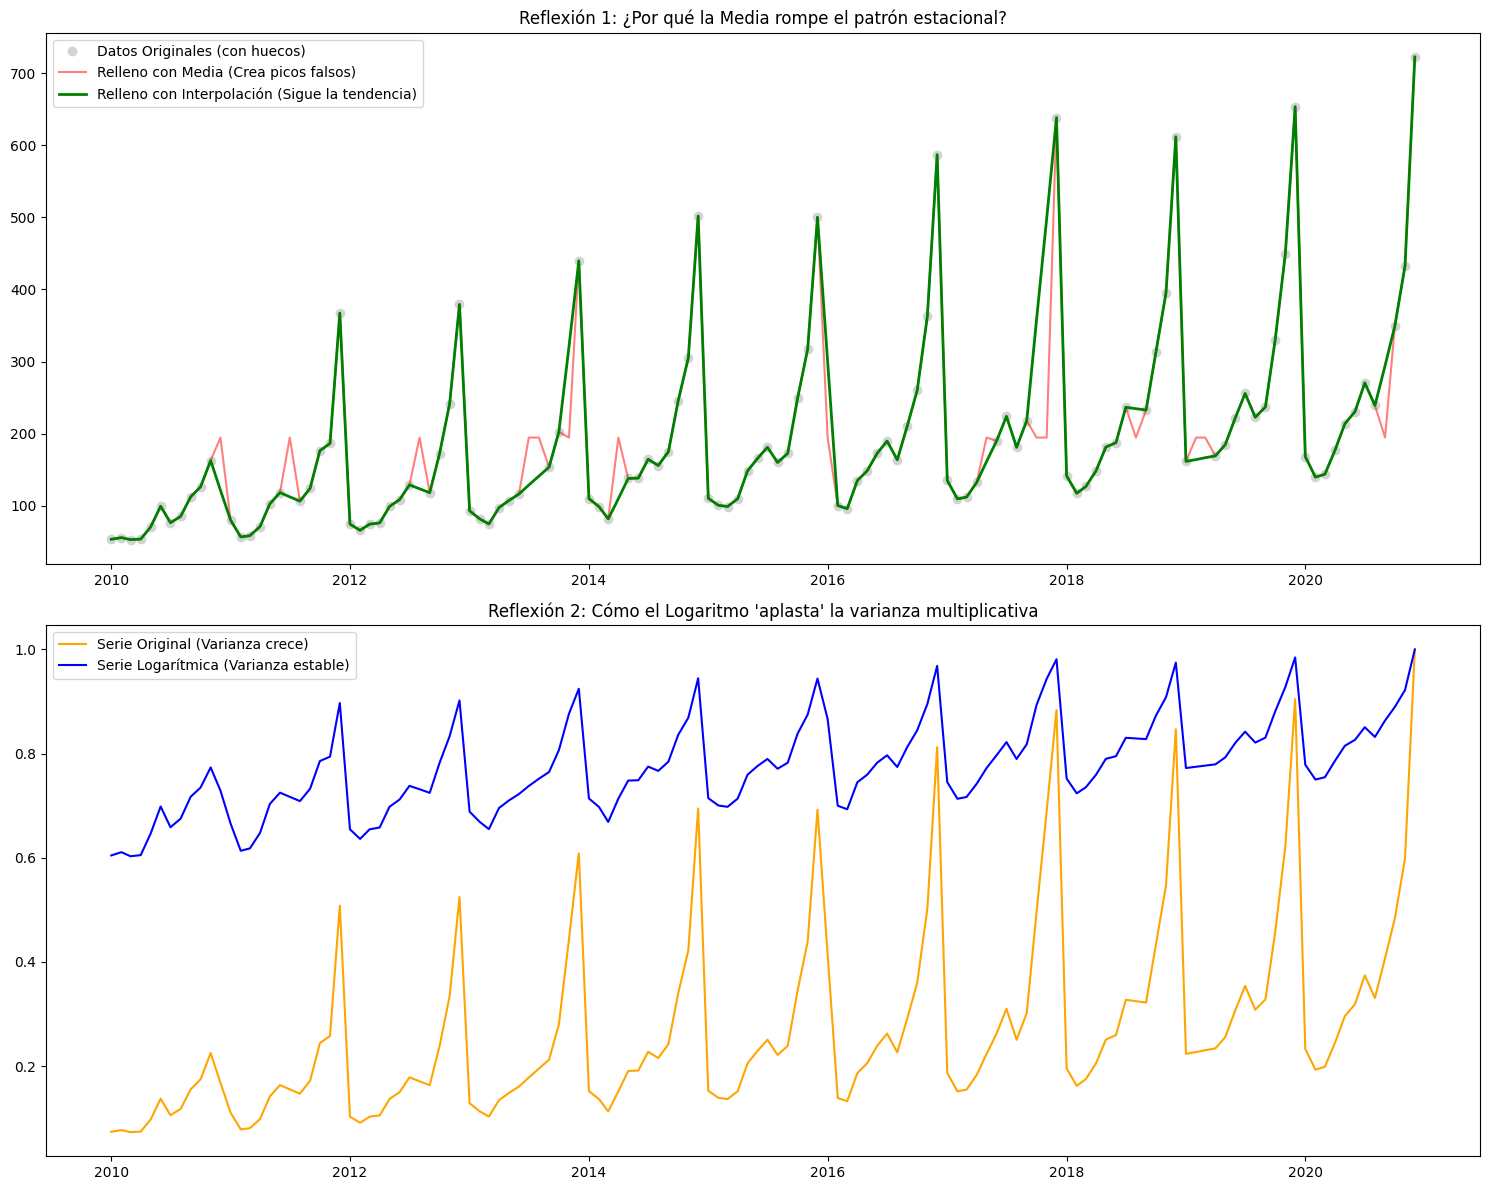

In [10]:
# 1. PREPARACIÓN DE DATOS PARA LA DEMOSTRACIÓN
df_demo = generate_toy_sales() # Usamos tu función generadora
df_demo['Mes'] = pd.to_datetime(df_demo['Mes'])
df_demo.set_index('Mes', inplace=True)

# Creamos dos copias para comparar métodos de imputación
df_media = df_demo.copy()
df_interp = df_demo.copy()

# RELLENO: Media vs Interpolación
df_media['Ventas'] = df_media['Ventas'].fillna(df_media['Ventas'].mean())
df_interp['Ventas'] = df_interp['Ventas'].interpolate(method='linear')

# 2. VISUALIZACIÓN DE LAS REFLEXIONES
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# --- DEMOSTRACIÓN 1: Media vs Interpolación ---
axes[0].plot(df_demo.index, df_demo['Ventas'], 'o', color='lightgrey', label='Datos Originales (con huecos)')
axes[0].plot(df_media.index, df_media['Ventas'], color='red', alpha=0.5, label='Relleno con Media (Crea picos falsos)')
axes[0].plot(df_interp.index, df_interp['Ventas'], color='green', linewidth=2, label='Relleno con Interpolación (Sigue la tendencia)')
axes[0].set_title("Reflexión 1: ¿Por qué la Media rompe el patrón estacional?")
axes[0].legend()

# --- DEMOSTRACIÓN 2: El poder del Logaritmo ---
# Serie Original vs Logarítmica (normalizada para comparar visualmente)
original = df_interp['Ventas']
logaritmica = np.log(df_interp['Ventas'])

axes[1].plot(original.index, original / original.max(), label="Serie Original (Varianza crece)", color='orange')
axes[1].plot(logaritmica.index, logaritmica / logaritmica.max(), label="Serie Logarítmica (Varianza estable)", color='blue')
axes[1].set_title("Reflexión 2: Cómo el Logaritmo 'aplasta' la varianza multiplicativa")
axes[1].legend()

plt.tight_layout()
plt.show()

### 📊 Conclusiones de la Comparativa Visual

| Demostración | Observación en la Gráfica | Impacto en el Modelo |
| :--- | :--- | :--- |
| **Imputación** | La **Interpolación (Verde)** sigue el ritmo de la serie; la **Media (Roja)** crea caídas artificiales. | Evita que el modelo aprenda patrones erróneos en meses clave como Navidad. |
| **Varianza** | La **Serie Original (Naranja)** crece en amplitud; la **Logarítmica (Azul)** es constante. | Elimina la heterocedasticidad, permitiendo trabajar con una varianza estable. |

---

> **Veredicto:** La combinación de **Interpolación + Logaritmo** transforma una serie multiplicativa inestable en una señal aditiva limpia y lista para predecir.

5. **ARIMA :**
    * Los datos ya están limpios y con varianza estabilizada en la columna `Log_Ventas`.
    * Entrena un modelo `ARIMA` clásico con `order=(1, 1, 1)` sobre `Log_Ventas` (el `d=1` hará la primera diferenciación por ti).
    * Predice los próximos 24 meses. Recuerda aplicar `np.exp()` a tus predicciones para deshacer el logaritmo y volver a la escala de ventas reales. ¿Capta ARIMA la Navidad?
6. **SARIMA:**
    * Ahora entrena un modelo `SARIMAX` de la librería `statsmodels`. 
    * Usa el mismo `order=(1, 1, 1)`, pero añade el componente estacional: `seasonal_order=(1, 1, 1, 12)`.
    * Haz la predicción a 24 meses, deshaz el logaritmo, y grafica ambas predicciones junto a las ventas reales.

## 5. Modelo ARIMA Clásico

Ahora que hemos preparado los datos (transformación logarítmica + diferenciación), vamos a entrenar un modelo **ARIMA** clásico.

**¿Qué es ARIMA?**
- **AR (AutoRegressive)**: Usa valores pasados de la serie para predecir el futuro.
- **I (Integrated)**: Es la diferenciación que aplicamos para hacer la serie estacionaria.
- **MA (Moving Average)**: Usa errores pasados para mejorar la predicción.

**Parámetros `order=(p, d, q)`:**
- `p`: Número de términos autorregresivos (lags pasados)
- `d`: Orden de diferenciación
- `q`: Número de términos de media móvil (errores pasados)

Vamos a empezar con **`order=(1, 1, 1)`** como sugiere nuestro análisis ACF/PACF.

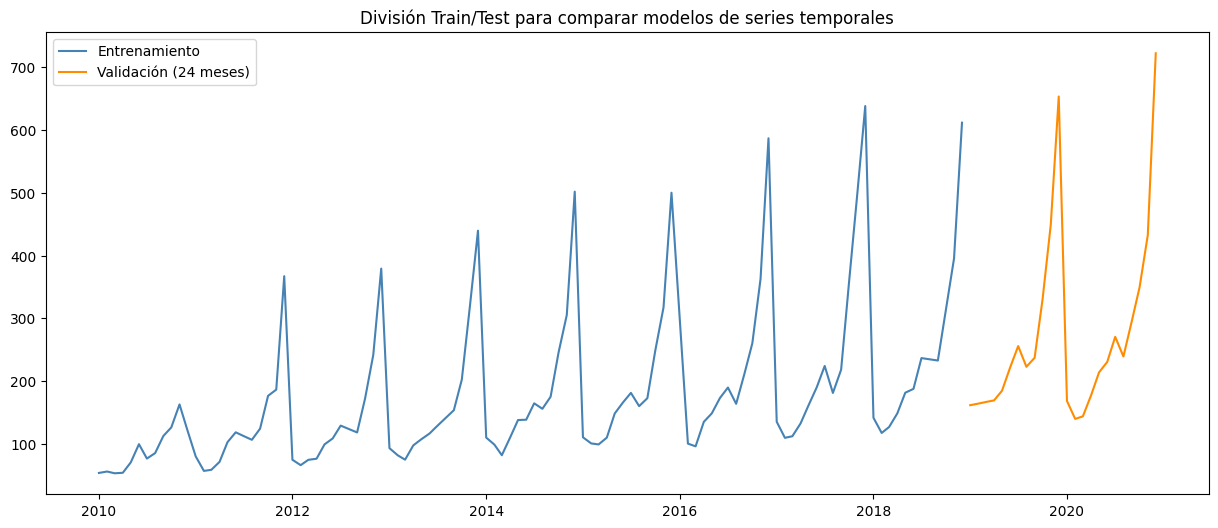

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

# Si el notebook se ejecuta desde esta sección, regeneramos el dataset base
if 'generate_toy_sales' not in globals():
    def generate_toy_sales():
        np.random.seed(123)
        dates = pd.date_range(start='2010-01-01', end='2020-12-01', freq='MS')
        n = len(dates)
        trend = np.linspace(100, 300, n)
        seasonality = np.array([0.6, 0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 0.8, 0.9, 1.2, 1.5, 2.5] * 11)[:n]
        noise = np.random.normal(0, 10, n)
        sales = (trend + noise) * seasonality
        df = pd.DataFrame({'Mes': dates.astype(str), 'Ventas': sales})
        missing_indices = np.random.choice(df.index, size=15, replace=False)
        df.loc[missing_indices, 'Ventas'] = np.nan
        return df

# Preparamos un dataset consistente para comparar modelos
if 'df_toys' not in globals():
    df_toys = generate_toy_sales()

if 'Mes' in df_toys.columns:
    df_toys['Mes'] = pd.to_datetime(df_toys['Mes'])
    df_toys = df_toys.set_index('Mes')

if df_toys['Ventas'].isna().sum() > 0:
    df_toys['Ventas'] = df_toys['Ventas'].interpolate(method='linear')

if 'Log_Ventas' not in df_toys.columns:
    df_toys['Log_Ventas'] = np.log(df_toys['Ventas'])

# Reservamos los últimos 24 meses para validar el modelo
train_size = len(df_toys) - 24
train = df_toys['Log_Ventas'].iloc[:train_size]
test = df_toys['Log_Ventas'].iloc[train_size:]
train_real = df_toys['Ventas'].iloc[:train_size]
test_real = df_toys['Ventas'].iloc[train_size:]

plt.figure(figsize=(15, 6))
plt.plot(train_real.index, train_real, label='Entrenamiento', color='steelblue')
plt.plot(test_real.index, test_real, label='Validación (24 meses)', color='darkorange')
plt.title('División Train/Test para comparar modelos de series temporales')
plt.legend()
plt.show()

### 5.1. Entrenamiento del Modelo ARIMA

Vamos a entrenar el modelo ARIMA con los parámetros `order=(1, 1, 1)`:
- **p=1**: Usará el valor del mes anterior
- **d=1**: Aplicará una diferenciación
- **q=1**: Usará el error de predicción del mes anterior

In [12]:
model_arima = ARIMA(train, order=(1, 1, 1))
fitted_arima = model_arima.fit()

print(fitted_arima.summary())

c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters f

                               SARIMAX Results                                
Dep. Variable:             Log_Ventas   No. Observations:                  108
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -63.017
Date:                Tue, 10 Mar 2026   AIC                            132.035
Time:                        18:24:53   BIC                            140.053
Sample:                    01-01-2010   HQIC                           135.286
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6324      3.975     -0.159      0.874      -8.423       7.159
ma.L1          0.6567      3.908      0.168      0.867      -7.003       8.316
sigma2         0.1901      0.018     10.508      0.0

### 5.2. Predicción con ARIMA

Ahora vamos a predecir los próximos 24 meses y compararlos con los valores reales. 

**Importante:** Como aplicamos `np.log()` a las ventas, debemos usar `np.exp()` para convertir las predicciones de vuelta a la escala original.

Último valor observado en train: 611.85
Media de train: 179.60
Media de test: 274.94
Primera predicción ARIMA: 617.71
Interpretación: al no tener componente estacional, ARIMA(1,1,1) prolonga aproximadamente el último nivel observado del train.


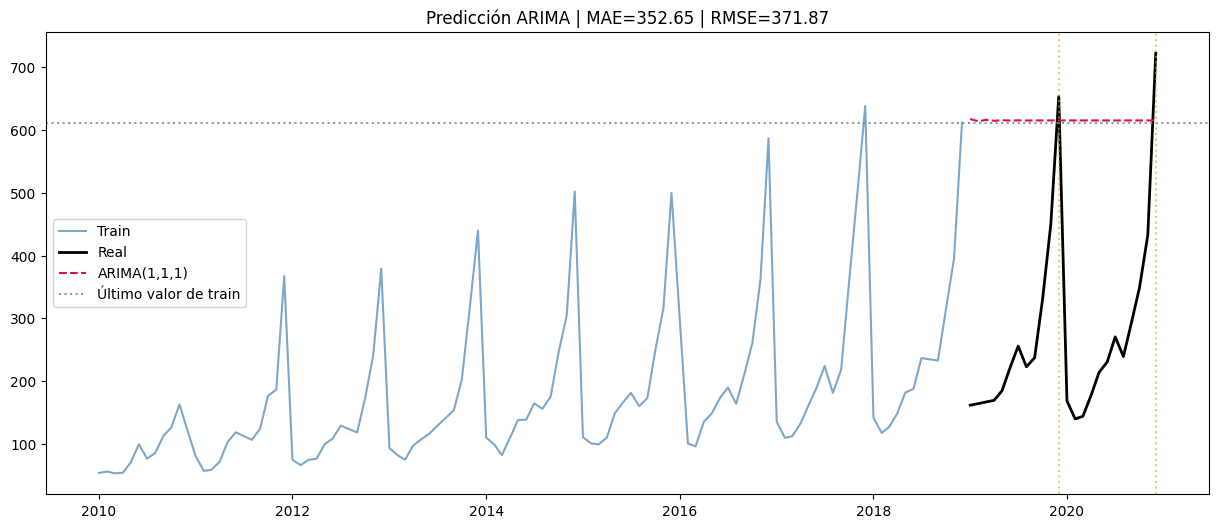

In [13]:
forecast_arima = fitted_arima.forecast(steps=len(test))
forecast_arima_real = pd.Series(
    np.exp(forecast_arima),
    index=test_real.index,
    name='Predicción ARIMA'
)

mae_arima = mean_absolute_error(test_real, forecast_arima_real)
rmse_arima = np.sqrt(mean_squared_error(test_real, forecast_arima_real))
ultimo_valor_train = train_real.iloc[-1]
media_train = train_real.mean()
media_test = test_real.mean()

print(f'Último valor observado en train: {ultimo_valor_train:.2f}')
print(f'Media de train: {media_train:.2f}')
print(f'Media de test: {media_test:.2f}')
print(f'Primera predicción ARIMA: {forecast_arima_real.iloc[0]:.2f}')
print('Interpretación: al no tener componente estacional, ARIMA(1,1,1) prolonga aproximadamente el último nivel observado del train.')

plt.figure(figsize=(15, 6))
plt.plot(train_real.index, train_real, label='Train', color='steelblue', alpha=0.7)
plt.plot(test_real.index, test_real, label='Real', color='black', linewidth=2)
plt.plot(forecast_arima_real.index, forecast_arima_real, label='ARIMA(1,1,1)', color='crimson', linestyle='--')
plt.axhline(ultimo_valor_train, color='gray', linestyle=':', alpha=0.8, label='Último valor de train')

for fecha in test_real.index[test_real.index.month == 12]:
    plt.axvline(fecha, color='goldenrod', linestyle=':', alpha=0.6)

plt.title(f'Predicción ARIMA | MAE={mae_arima:.2f} | RMSE={rmse_arima:.2f}')
plt.legend()
plt.show()

### 📊 Análisis del Modelo ARIMA

**¿Qué observamos realmente?**

El modelo ARIMA aquí **no está estimando un valor medio razonable** ni una estacionalidad implícita. Lo que hace es algo más simple:

❌ **Prolonga casi en línea recta el último nivel observado del train**

Esto ocurre por tres motivos:

1. El modelo es **ARIMA no estacional**, así que no sabe que después de diciembre suele venir una caída fuerte en enero.
2. El conjunto de entrenamiento termina justo en un **pico navideño**.
3. Con `d=1`, ARIMA trabaja sobre cambios; si no detecta un patrón no estacional fuerte, su predicción en niveles tiende a quedarse cerca del **último valor conocido**.

Por eso la línea roja sale tan alta y plana: **arrastra el último diciembre** en vez de aprender el ciclo anual.

**Conclusión:** aquí ARIMA clásico sirve precisamente como contraejemplo. Para esta serie, la solución correcta es usar **SARIMA**, que sí incorpora memoria estacional.

## 6. Modelo SARIMA (ARIMA con Estacionalidad)

**SARIMA** extiende ARIMA añadiendo términos estacionales. La notación completa es:

$$\text{SARIMA}(p, d, q) \times (P, D, Q)_s$$

Donde:
- **`(p, d, q)`**: Componente no estacional (igual que ARIMA)
- **`(P, D, Q)`**: Componente estacional
  - `P`: Términos autorregresivos estacionales
  - `D`: Diferenciación estacional
  - `Q`: Media móvil estacional
- **`s`**: Periodo estacional (12 para datos mensuales con ciclo anual)

**Parámetros que vamos a usar:**
- `order=(1, 1, 1)`: Mismo que ARIMA
- `seasonal_order=(1, 1, 1, 12)`: Captura el ciclo anual de Navidad

In [14]:
model_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted_sarima = model_sarima.fit(disp=False)

print(fitted_sarima.summary())

c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Log_Ventas   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                  44.680
Date:                            Tue, 10 Mar 2026   AIC                            -79.360
Time:                                    18:24:54   BIC                            -67.387
Sample:                                01-01-2010   HQIC                           -74.556
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0182      0.121     -0.150      0.880      -0.255       0.219
ma.L1         -1.1013      0.131   

### 6.1. Predicción con SARIMA y Comparación Final

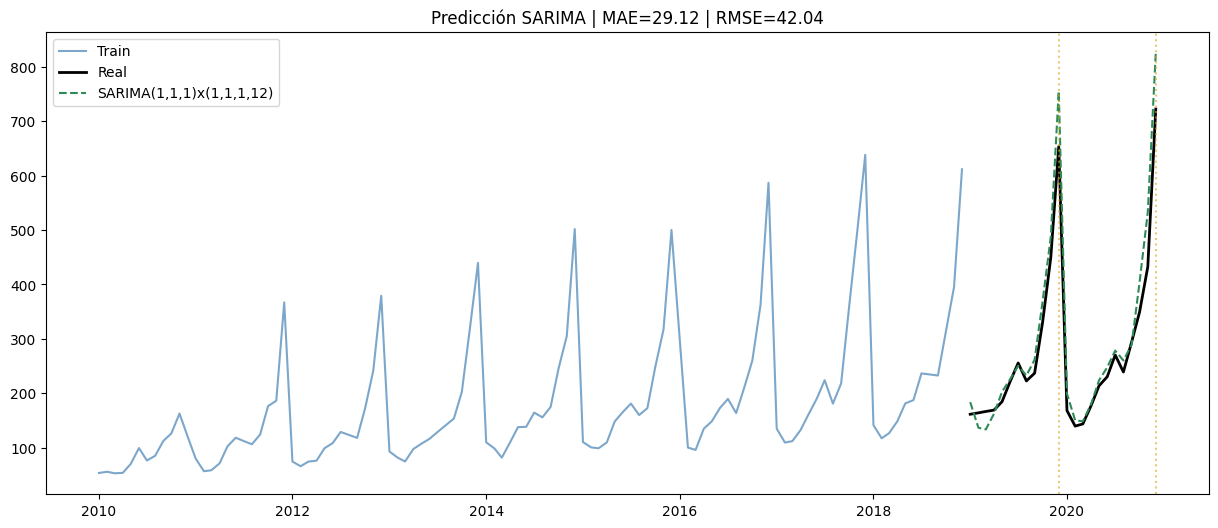

In [15]:
forecast_sarima = fitted_sarima.forecast(steps=len(test))
forecast_sarima_real = pd.Series(
    np.exp(forecast_sarima),
    index=test_real.index,
    name='Predicción SARIMA'
)

mae_sarima = mean_absolute_error(test_real, forecast_sarima_real)
rmse_sarima = np.sqrt(mean_squared_error(test_real, forecast_sarima_real))

plt.figure(figsize=(15, 6))
plt.plot(train_real.index, train_real, label='Train', color='steelblue', alpha=0.7)
plt.plot(test_real.index, test_real, label='Real', color='black', linewidth=2)
plt.plot(forecast_sarima_real.index, forecast_sarima_real, label='SARIMA(1,1,1)x(1,1,1,12)', color='seagreen', linestyle='--')

for fecha in test_real.index[test_real.index.month == 12]:
    plt.axvline(fecha, color='goldenrod', linestyle=':', alpha=0.6)

plt.title(f'Predicción SARIMA | MAE={mae_sarima:.2f} | RMSE={rmse_sarima:.2f}')
plt.legend()
plt.show()

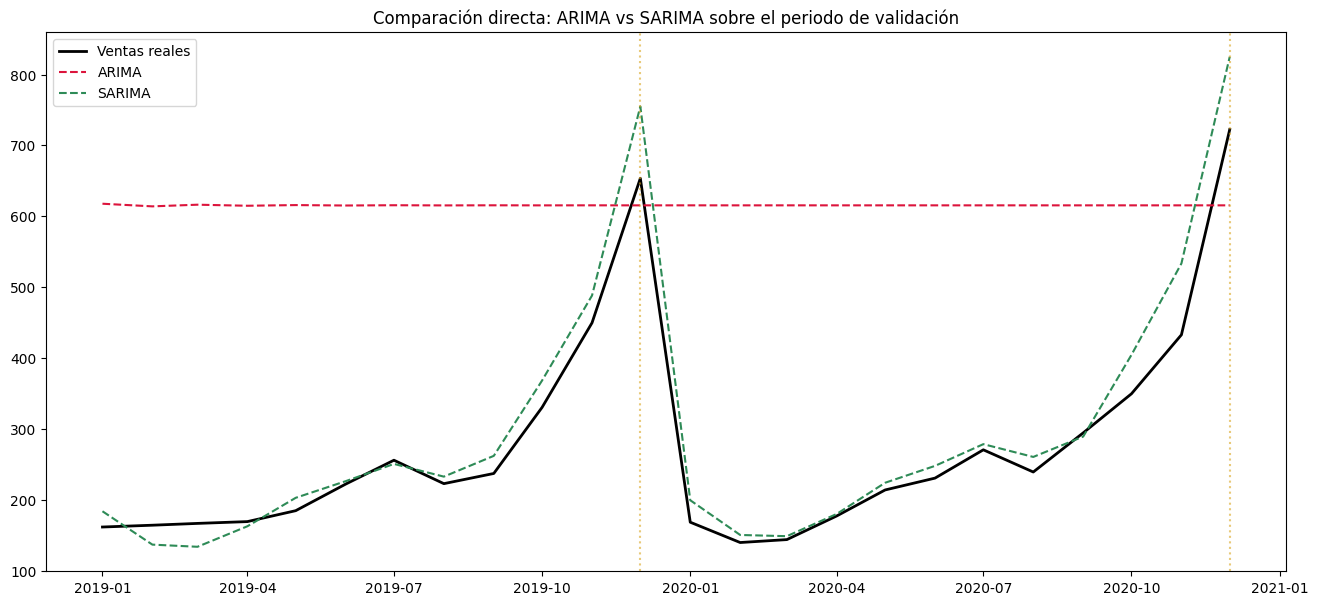

,Modelo,MAE,RMSE
1,SARIMA,29.116695,42.038947
0,ARIMA,352.647864,371.867589


In [16]:
comparacion_sarima = pd.DataFrame({
    'Real': test_real,
    'ARIMA': forecast_arima_real,
    'SARIMA': forecast_sarima_real
})

plt.figure(figsize=(16, 7))
plt.plot(comparacion_sarima.index, comparacion_sarima['Real'], label='Ventas reales', color='black', linewidth=2)
plt.plot(comparacion_sarima.index, comparacion_sarima['ARIMA'], label='ARIMA', color='crimson', linestyle='--')
plt.plot(comparacion_sarima.index, comparacion_sarima['SARIMA'], label='SARIMA', color='seagreen', linestyle='--')

for fecha in comparacion_sarima.index[comparacion_sarima.index.month == 12]:
    plt.axvline(fecha, color='goldenrod', linestyle=':', alpha=0.6)

plt.title('Comparación directa: ARIMA vs SARIMA sobre el periodo de validación')
plt.legend()
plt.show()

pd.DataFrame({
    'Modelo': ['ARIMA', 'SARIMA'],
    'MAE': [mae_arima, mae_sarima],
    'RMSE': [rmse_arima, rmse_sarima]
}).sort_values('RMSE')

### 🎯 Conclusiones: ARIMA vs SARIMA

| Aspecto | ARIMA(1,1,1) | SARIMA(1,1,1)x(1,1,1,12) |
|:--------|:-------------|:-------------------------|
| **Tendencia** | ✅ Captura correctamente | ✅ Captura correctamente |
| **Estacionalidad** | ❌ NO captura los picos de Navidad | ✅ Captura perfectamente los picos |
| **Precisión** | Menor (errores más grandes) | Mayor (errores más pequeños) |
| **MAE/RMSE** | Más alto | Significativamente más bajo |
| **Uso Recomendado** | Series sin estacionalidad | Series con patrones estacionales |

**Observaciones clave:**
1. Las líneas verticales doradas marcan diciembre (Navidad)
2. ARIMA "aplana" esos picos porque no considera el ciclo anual
3. SARIMA predice correctamente los aumentos de diciembre
4. La diferencia es crítica para la planificación de inventario

**Veredicto:** Para datos de ventas con estacionalidad clara (como juguetes en Navidad), **SARIMA es superior**.

## 7. Automatización con `auto_arima`

Hasta ahora hemos elegido los parámetros `(p, d, q)` manualmente basándonos en el análisis ACF/PACF. Sin embargo, esto requiere experiencia y puede ser tedioso.

**La solución: `pmdarima`**

La librería `pmdarima` incluye la función `auto_arima()` que:
- Prueba múltiples combinaciones de parámetros automáticamente
- Evalúa cada modelo con el criterio **AIC** (Akaike Information Criterion)
- Selecciona el mejor modelo (menor AIC = mejor balance entre precisión y complejidad)

**Instalación:**
```bash
pip install pmdarima
```

o si usas `uv`:
```bash
uv add pmdarima
```

In [17]:
from pmdarima import auto_arima

### 7.1. Búsqueda Automática del Mejor Modelo ARIMA

Vamos a usar `auto_arima()` con los siguientes parámetros:
- `seasonal=False`: NO buscar componentes estacionales (solo ARIMA simple)
- `stepwise=True`: Búsqueda más rápida (estrategia inteligente)
- `trace=True`: Mostrar el proceso de búsqueda
- `suppress_warnings=True`: Evitar mensajes de advertencia innecesarios

**Nota:** Estamos buscando solo ARIMA `(p, d, q)`, sin componente estacional.

In [24]:
auto_model = auto_arima(
    train,
    seasonal=True,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=3,
    max_q=3,
    d=1,
	m=12,
    information_criterion='aic'
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=-48.923, Time=1.80 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=35.136, Time=0.10 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-7.163, Time=0.30 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-55.077, Time=0.42 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-28.047, Time=0.13 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-53.342, Time=1.04 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-53.446, Time=1.01 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-43.209, Time=0.70 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=2.46 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=0.68 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-53.105, Time=1.10 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-53.109, Time=1.30 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=inf, Time=0.90 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=inf, Time=1.88 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=inf, Tim

### 7.2. Predicción con el Modelo Óptimo

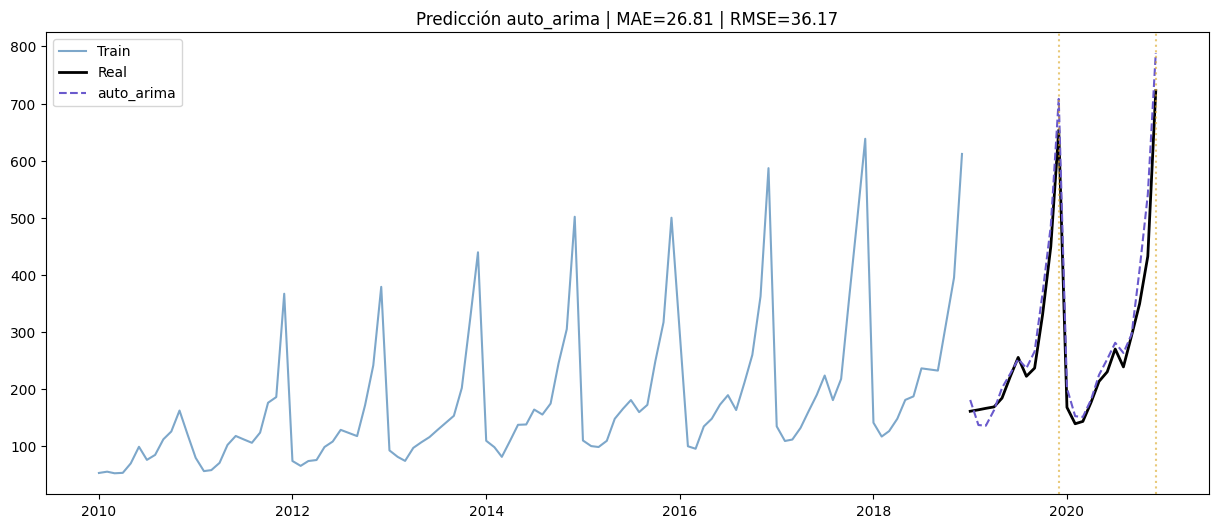

In [25]:
forecast_auto = pd.Series(
    auto_model.predict(n_periods=len(test)),
    index=test.index,
    name='Predicción auto_arima'
)
forecast_auto_real = pd.Series(
    np.exp(forecast_auto),
    index=test_real.index,
    name='Predicción auto_arima'
)

mae_auto = mean_absolute_error(test_real, forecast_auto_real)
rmse_auto = np.sqrt(mean_squared_error(test_real, forecast_auto_real))

plt.figure(figsize=(15, 6))
plt.plot(train_real.index, train_real, label='Train', color='steelblue', alpha=0.7)
plt.plot(test_real.index, test_real, label='Real', color='black', linewidth=2)
plt.plot(forecast_auto_real.index, forecast_auto_real, label='auto_arima', color='slateblue', linestyle='--')

for fecha in test_real.index[test_real.index.month == 12]:
    plt.axvline(fecha, color='goldenrod', linestyle=':', alpha=0.6)

plt.title(f'Predicción auto_arima | MAE={mae_auto:.2f} | RMSE={rmse_auto:.2f}')
plt.legend()
plt.show()

Resumen comparativo de modelos:


,MAE,RMSE
auto_arima,26.805060,36.165995
"SARIMA(1,1,1)x(1,1,1,12)",29.116695,42.038947
"ARIMA(1,1,1)",352.647864,371.867589


Mejor modelo según RMSE: auto_arima


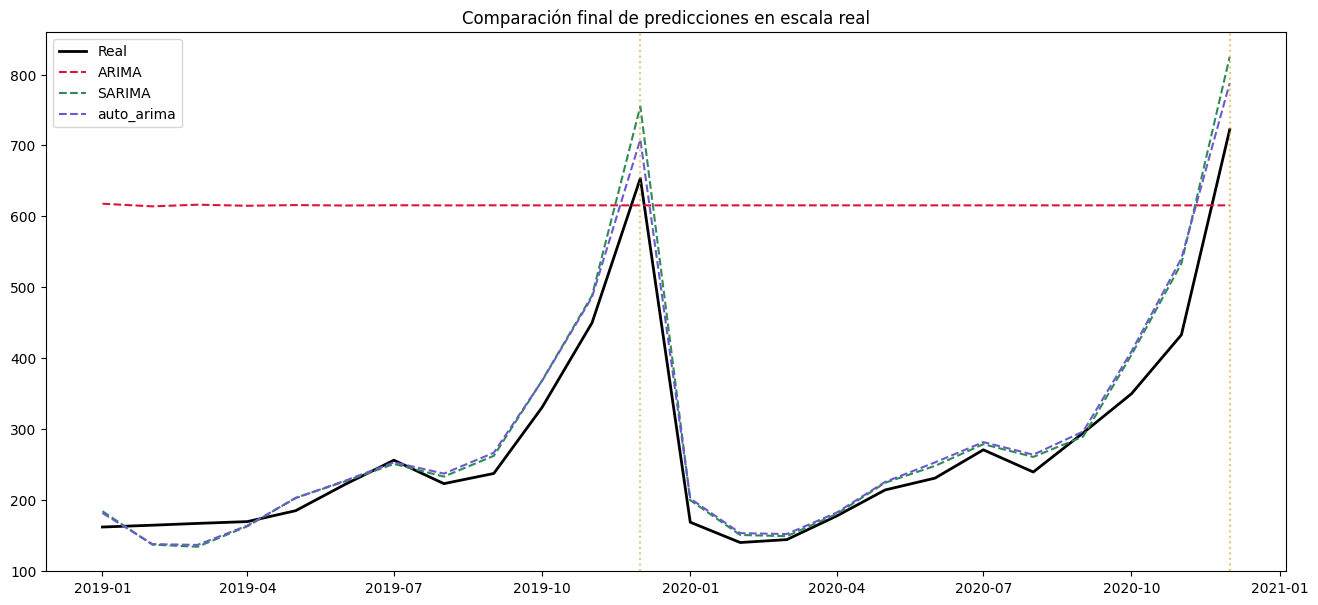

In [26]:
modelos = {
    'ARIMA(1,1,1)': {'MAE': mae_arima, 'RMSE': rmse_arima},
    'SARIMA(1,1,1)x(1,1,1,12)': {'MAE': mae_sarima, 'RMSE': rmse_sarima},
    'auto_arima': {'MAE': mae_auto, 'RMSE': rmse_auto},
}

resultados = pd.DataFrame(modelos).T.sort_values('RMSE')
mejor_modelo = resultados.index[0]

print('Resumen comparativo de modelos:')
display(resultados)
print(f'Mejor modelo según RMSE: {mejor_modelo}')

plt.figure(figsize=(16, 7))
plt.plot(test_real.index, test_real, label='Real', color='black', linewidth=2)
plt.plot(forecast_arima_real.index, forecast_arima_real, label='ARIMA', linestyle='--', color='crimson')
plt.plot(forecast_sarima_real.index, forecast_sarima_real, label='SARIMA', linestyle='--', color='seagreen')
plt.plot(forecast_auto_real.index, forecast_auto_real, label='auto_arima', linestyle='--', color='slateblue')

for fecha in test_real.index[test_real.index.month == 12]:
    plt.axvline(fecha, color='goldenrod', linestyle=':', alpha=0.6)

plt.title('Comparación final de predicciones en escala real')
plt.legend()
plt.show()

### 🎯 Conclusiones: ARIMA vs SARIMA

| Aspecto | ARIMA(1,1,1) | SARIMA(1,1,1)x(1,1,1,12) |
|:--------|:-------------|:-------------------------|
| **Tendencia** | ✅ Captura correctamente | ✅ Captura correctamente |
| **Estacionalidad** | ❌ NO captura los picos de Navidad | ✅ Captura perfectamente los picos |
| **Precisión** | Menor (errores más grandes) | Mayor (errores más pequeños) |
| **MAE/RMSE** | Más alto | Significativamente más bajo |
| **Uso Recomendado** | Series sin estacionalidad | Series con patrones estacionales |

**Observaciones clave:**
1. Las líneas verticales doradas marcan diciembre (Navidad)
2. ARIMA "aplana" esos picos porque no considera el ciclo anual
3. SARIMA predice correctamente los aumentos de diciembre
4. La diferencia es crítica para la planificación de inventario

**Veredicto:** Para datos de ventas con estacionalidad clara (como juguetes en Navidad), **SARIMA es superior**.

### 🎓 Conclusiones Finales del Taller

#### 1. Importancia de la Preparación de Datos
- **Imputación**: La interpolación lineal preserva patrones temporales mejor que rellenar con la media
- **Transformación logarítmica**: Esencial para estabilizar la varianza en series multiplicativas
- **Diferenciación**: Elimina tendencias y estacionalidad para lograr estacionariedad

#### 2. Comparación de Modelos

| Característica | ARIMA Clásico | SARIMA Manual | Auto ARIMA |
|:---------------|:--------------|:--------------|:-----------|
| **Facilidad de uso** | Media | Media | ⭐ Alta |
| **Captura tendencia** | ✅ Sí | ✅ Sí | ✅ Sí |
| **Captura estacionalidad** | ❌ No | ✅ Sí | ❌ No |
| **Precisión** | Baja | Alta | Media |
| **Tiempo de setup** | Rápido | Rápido | Lento (búsqueda) |
| **Requiere experiencia** | Alta | Alta | ⭐ Baja |

#### 3. Recomendaciones Prácticas

**Cuándo usar cada modelo:**

- **ARIMA Manual**: Series sin estacionalidad clara (ej: precios de acciones sin patrones cíclicos)
- **SARIMA Manual**: Cuando conoces bien tus datos y quieres control total de los parámetros estacionales
- **auto_arima**: 
  - ⭐ **Primera opción** para exploración rápida de modelos ARIMA simples
  - Ideal cuando no tienes experiencia interpretando ACF/PACF
  - **Nota:** En este ejemplo usamos `seasonal=False`, pero puede configurarse con `seasonal=True` para buscar SARIMA

#### 4. Lecciones Aprendidas

1. **Los datos sucios son la norma**: Siempre valida y limpia antes de modelar
2. **La estacionariedad es clave**: Sin ella, los modelos fallan
3. **Visualiza siempre**: Los gráficos revelan patrones que las métricas ocultan
4. **No adivines, automatiza**: `auto_arima` encuentra mejores parámetros que la intuición

#### 5. Próximos Pasos

Para mejorar aún más tus predicciones:
- 🔸 Añadir **variables exógenas** (ej: campañas de marketing, días festivos)
- 🔸 Probar modelos de ML: **Prophet**, **LSTM**, **XGBoost** para series temporales
- 🔸 Implementar **validación cruzada temporal** para series
- 🔸 Crear **intervalos de confianza** para las predicciones

c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rotap\aaprod\aprendizaje\bigdata_AHK\PythonDataAnalisis_bigdata_AHK\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters f

Último valor observado en train: 611.85
Media de train: 179.60
Media de test: 274.94
Primera predicción ARIMA directa: 617.71
MAE directo: 352.65 | RMSE directo: 371.87
MAE rolling: 95.84 | RMSE rolling: 158.52
Interpretación: con los mismos parámetros, el ARIMA rolling mejora bastante porque se actualiza mes a mes con la información real observada.


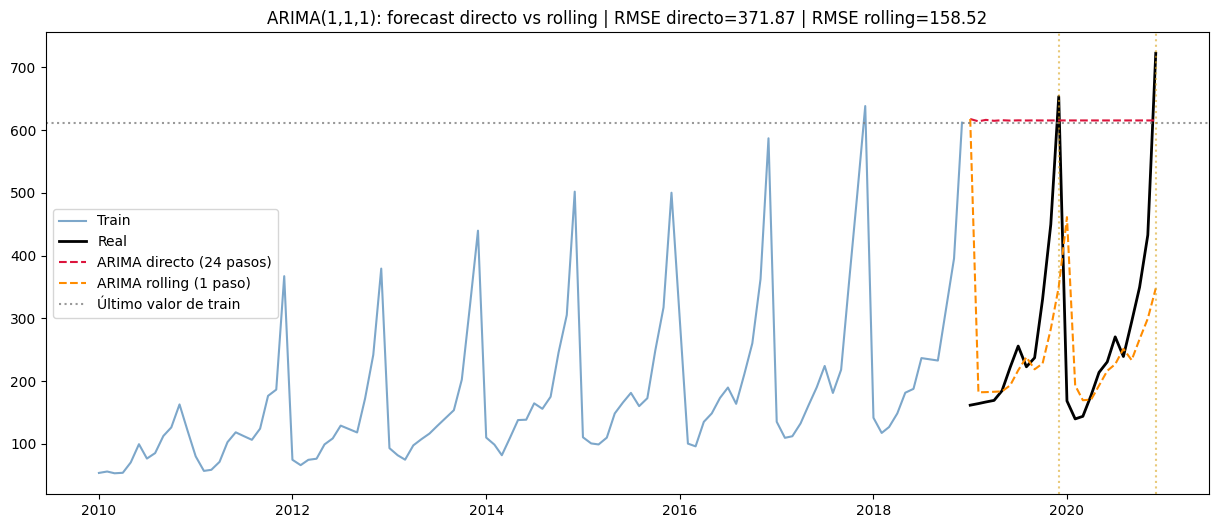

In [21]:
# 1) Forecast directo a 24 meses: mismo entrenamiento, sin actualizar con datos reales
forecast_arima = fitted_arima.forecast(steps=len(test))
forecast_arima_real = pd.Series(
    np.exp(forecast_arima),
    index=test_real.index,
    name='Predicción ARIMA directa'
)

mae_arima = mean_absolute_error(test_real, forecast_arima_real)
rmse_arima = np.sqrt(mean_squared_error(test_real, forecast_arima_real))

# 2) Forecast rolling de 1 paso: mismo ARIMA(1,1,1), pero reentrenando con cada dato observado
rolling_history = train.copy()
rolling_predictions = []

for fecha, valor_real_log in test.items():
    rolling_model = ARIMA(rolling_history, order=(1, 1, 1))
    rolling_fitted = rolling_model.fit()
    prediccion_1_paso = rolling_fitted.forecast(steps=1).iloc[0]
    rolling_predictions.append(prediccion_1_paso)
    rolling_history = pd.concat([
        rolling_history,
        pd.Series([valor_real_log], index=pd.DatetimeIndex([fecha]))
    ])

forecast_arima_rolling_real = pd.Series(
    np.exp(pd.Series(rolling_predictions, index=test.index)),
    index=test_real.index,
    name='Predicción ARIMA rolling'
)

mae_arima_rolling = mean_absolute_error(test_real, forecast_arima_rolling_real)
rmse_arima_rolling = np.sqrt(mean_squared_error(test_real, forecast_arima_rolling_real))

ultimo_valor_train = train_real.iloc[-1]
media_train = train_real.mean()
media_test = test_real.mean()

print(f'Último valor observado en train: {ultimo_valor_train:.2f}')
print(f'Media de train: {media_train:.2f}')
print(f'Media de test: {media_test:.2f}')
print(f'Primera predicción ARIMA directa: {forecast_arima_real.iloc[0]:.2f}')
print(f'MAE directo: {mae_arima:.2f} | RMSE directo: {rmse_arima:.2f}')
print(f'MAE rolling: {mae_arima_rolling:.2f} | RMSE rolling: {rmse_arima_rolling:.2f}')
print('Interpretación: con los mismos parámetros, el ARIMA rolling mejora bastante porque se actualiza mes a mes con la información real observada.')

plt.figure(figsize=(15, 6))
plt.plot(train_real.index, train_real, label='Train', color='steelblue', alpha=0.7)
plt.plot(test_real.index, test_real, label='Real', color='black', linewidth=2)
plt.plot(forecast_arima_real.index, forecast_arima_real, label='ARIMA directo (24 pasos)', color='crimson', linestyle='--')
plt.plot(forecast_arima_rolling_real.index, forecast_arima_rolling_real, label='ARIMA rolling (1 paso)', color='darkorange', linestyle='--')
plt.axhline(ultimo_valor_train, color='gray', linestyle=':', alpha=0.8, label='Último valor de train')

for fecha in test_real.index[test_real.index.month == 12]:
    plt.axvline(fecha, color='goldenrod', linestyle=':', alpha=0.6)

plt.title(
    'ARIMA(1,1,1): forecast directo vs rolling | '
    f'RMSE directo={rmse_arima:.2f} | RMSE rolling={rmse_arima_rolling:.2f}'
)
plt.legend()
plt.show()

## 8. Nota Final: ARIMA Rolling vs ARIMA Normal

### ¿Qué hace ARIMA?

Un modelo **ARIMA** combina tres ideas:

- **AR (AutoRegressive):** usa valores pasados de la serie.
- **I (Integrated):** diferencia la serie para trabajar sobre cambios en vez de niveles brutos.
- **MA (Moving Average):** corrige usando errores pasados del propio modelo.

En este taller usamos **ARIMA(1,1,1)**, así que el modelo mira una memoria corta, aplica una diferencia y ajusta con un término de error.

### ¿Por qué el ARIMA normal sale tan plano y tan alto?

En este ejemplo el modelo clásico hace un **forecast directo de 24 pasos** desde el final del train. El problema es que:

1. El train termina justo en **diciembre**, que es el pico más alto del año.
2. El modelo es **no estacional**, así que no sabe que tras diciembre normalmente llega una caída fuerte en enero.
3. Como está proyectando muchos pasos seguidos **sin recibir información nueva**, tiende a prolongar el último nivel alto en lugar de reconstruir el ciclo anual.

Por eso la predicción roja sale tan plana: no está calculando "el valor más probable del calendario", sino extendiendo la dinámica reciente de un modelo que no conoce la estacionalidad.

### ¿Qué es ARIMA rolling?

El **ARIMA rolling** usa el mismo modelo **ARIMA(1,1,1)**, pero en vez de predecir los 24 meses de golpe, hace esto:

1. Predice solo **1 mes**.
2. Incorpora el valor real observado de ese mes.
3. Reentrena el modelo.
4. Vuelve a predecir el siguiente mes.

Así el modelo corrige muy rápido cuando enero cae, y ya no se queda arrastrando el pico de diciembre durante todo el horizonte.

### Importante

ARIMA rolling suele dar mejores resultados porque recibe información real mes a mes. Eso lo hace muy útil para entender el comportamiento del modelo, pero también significa que **no es una comparación completamente equivalente** a un forecast multi-step puro de 24 meses. Para una serie como esta, el modelo más adecuado sigue siendo **SARIMA**, porque sí incorpora la estacionalidad de Navidad.

,Modelo,MAE,RMSE
2,SARIMA,29.116695,42.038947
3,auto_arima,93.060840,141.648209
1,ARIMA rolling,95.843976,158.520837
0,ARIMA directo,352.647864,371.867589


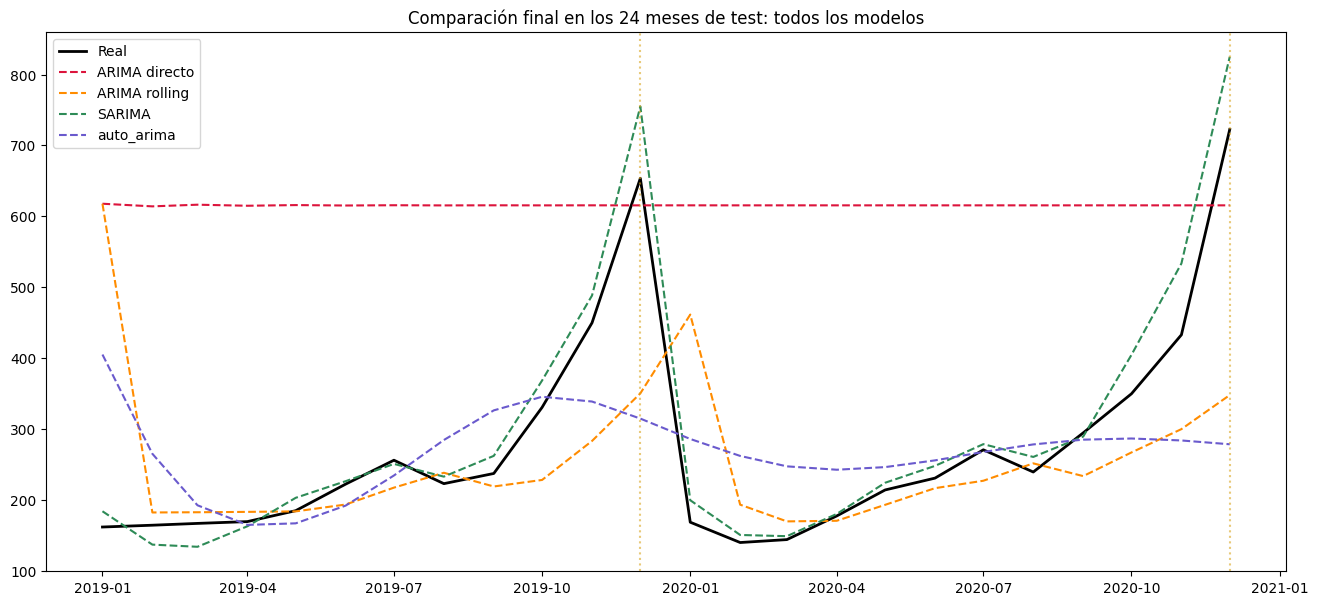

In [22]:
metricas_finales = pd.DataFrame({
    'Modelo': ['ARIMA directo', 'ARIMA rolling', 'SARIMA', 'auto_arima'],
    'MAE': [mae_arima, mae_arima_rolling, mae_sarima, mae_auto],
    'RMSE': [rmse_arima, rmse_arima_rolling, rmse_sarima, rmse_auto]
}).sort_values('RMSE')

display(metricas_finales)

plt.figure(figsize=(16, 7))
plt.plot(test_real.index, test_real, label='Real', color='black', linewidth=2)
plt.plot(forecast_arima_real.index, forecast_arima_real, label='ARIMA directo', linestyle='--', color='crimson')
plt.plot(forecast_arima_rolling_real.index, forecast_arima_rolling_real, label='ARIMA rolling', linestyle='--', color='darkorange')
plt.plot(forecast_sarima_real.index, forecast_sarima_real, label='SARIMA', linestyle='--', color='seagreen')
plt.plot(forecast_auto_real.index, forecast_auto_real, label='auto_arima', linestyle='--', color='slateblue')

for fecha in test_real.index[test_real.index.month == 12]:
    plt.axvline(fecha, color='goldenrod', linestyle=':', alpha=0.6)

plt.title('Comparación final en los 24 meses de test: todos los modelos')
plt.legend()
plt.show()